# Tox21 EDA — locking in modeling decisions

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from rdkit import Chem

sns.set_theme(style="whitegrid")

FIG_DIR = Path("../results/tox21_eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase", "NR-ER", "NR-ER-LBD",
    "NR-PPAR-gamma", "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
]
NR_TASKS = [t for t in TASKS if t.startswith("NR-")]
SR_TASKS = [t for t in TASKS if t.startswith("SR-")]

df = pd.read_csv("../data/processed/tox21_clean.csv", dtype={t: "float64" for t in TASKS})
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
assert df["mol"].notna().all(), "Some SMILES failed to parse"

splits = pd.read_csv("../data/processed/tox21_splits.csv")
df = df.merge(splits, on="smiles", how="left")
assert df["split"].notna().all()

print(f"Loaded {len(df)} molecules (SMILES validation and dedup already done upstream "
      f"in tox21_data_processing.py: 8 failed to parse, 183 duplicates removed).")
df.head()

Loaded 7823 molecules (SMILES validation and dedup already done upstream in tox21_data_processing.py: 8 failed to parse, 183 duplicates removed).


[21:37:06] WARNING: not removing hydrogen atom without neighbors


,smiles,mol_id,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol,split
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,TOX3021,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x12101df50>,train
1,CCN1C(=O)NC(c2ccccc2)C1=O,TOX3020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x12101dfc0>,train
2,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,TOX3024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x12101e030>,train
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,TOX3027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x12101e0a0>,train
4,CC(O)(P(=O)(O)O)P(=O)(O)O,TOX3028,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,<rdkit.Chem.rdchem.Mol object at 0x12101e110>,train


## 1. Missing rate & class balance per assay → masking + metric choice

Per assay: what fraction of molecules were never tested (missing rate), and
among those tested, what fraction are positive (class balance). These two
numbers together decide the loss (masked BCE, since assays are sparsely
tested) and the metric (AUC, since positives are rare on every assay).

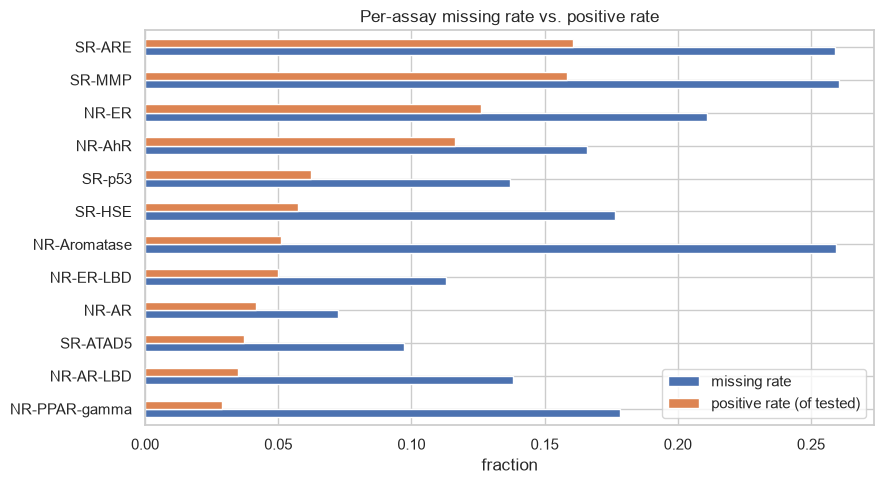

               n_negative  n_positive  positive_rate  missing_rate
NR-AR                6952         303          0.042         0.073
NR-AR-LBD            6506         235          0.035         0.138
NR-AhR               5765         760          0.116         0.166
NR-Aromatase         5500         295          0.051         0.259
NR-ER                5394         779          0.126         0.211
NR-ER-LBD            6593         345          0.050         0.113
NR-PPAR-gamma        6243         186          0.029         0.178
SR-ARE               4867         931          0.161         0.259
SR-ATAD5             6798         263          0.037         0.097
SR-HSE               6074         369          0.057         0.176
SR-MMP               4868         916          0.158         0.261
SR-p53               6332         420          0.062         0.137


In [2]:
missing_rate = df[TASKS].isna().mean()

class_balance = pd.DataFrame({
    task: df[task].dropna().value_counts()
    for task in TASKS
}).T.rename(columns={0.0: "n_negative", 1.0: "n_positive"})
class_balance["positive_rate"] = class_balance["n_positive"] / (
    class_balance["n_negative"] + class_balance["n_positive"]
)
class_balance["missing_rate"] = missing_rate

summary = class_balance[["missing_rate", "positive_rate"]].sort_values("positive_rate")

fig, ax = plt.subplots(figsize=(9, 5))
summary.plot(kind="barh", ax=ax)
ax.set_xlabel("fraction")
ax.set_title("Per-assay missing rate vs. positive rate")
ax.legend(["missing rate", "positive rate (of tested)"])
plt.tight_layout()
plt.savefig(FIG_DIR / "01_assay_summary.png", dpi=150)
plt.show()

print(class_balance[["n_negative", "n_positive", "positive_rate", "missing_rate"]].round(3))

## 2. Label co-occurrence → multi-task masking

How many of the 12 assays does a typical molecule have labels for, and are
the NR (nuclear receptor) and SR (stress response) panels tested together?
This decides whether masking needs to be per-assay or whether a coarser
per-panel mask would be sufficient.

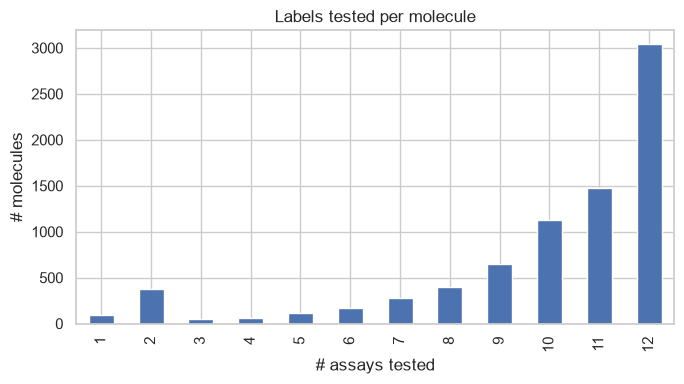

Labels tested per molecule:
1       97
2      378
3       48
4       61
5      111
6      167
7      277
8      396
9      646
10    1125
11    1479
12    3038
Name: count, dtype: int64

NR vs SR panel co-testing:
both panels    7336
NR only          33
SR only         454
neither           0
dtype: int64


In [3]:
labels_per_molecule = df[TASKS].notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
labels_per_molecule.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("# assays tested")
ax.set_ylabel("# molecules")
ax.set_title("Labels tested per molecule")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_label_cooccurrence.png", dpi=150)
plt.show()

has_nr = df[NR_TASKS].notna().any(axis=1)
has_sr = df[SR_TASKS].notna().any(axis=1)
panel_cooccurrence = pd.Series({
    "both panels": (has_nr & has_sr).sum(),
    "NR only": (has_nr & ~has_sr).sum(),
    "SR only": (~has_nr & has_sr).sum(),
    "neither": (~has_nr & ~has_sr).sum(),
})

print("Labels tested per molecule:")
print(labels_per_molecule.value_counts().sort_index())
print("\nNR vs SR panel co-testing:")
print(panel_cooccurrence)

## 3. Per-fold positive counts → metric reliability

The scaffold split (`data/processed/tox21_splits.csv`) groups similar
molecules together, which can concentrate a rare assay's positives into one
fold. Before trusting any per-assay AUC, check the absolute positive count
each assay gets in each fold. Assays with very few test-fold positives
(<20) give a noisy AUC; assays with zero are undefined and must be flagged
now, not discovered after training.

In [4]:
fold_positive_counts = pd.DataFrame({
    split: df.loc[df["split"] == split, TASKS].sum(skipna=True)
    for split in ["train", "val", "test"]
}).astype(int)

fold_tested_counts = pd.DataFrame({
    split: df.loc[df["split"] == split, TASKS].notna().sum()
    for split in ["train", "val", "test"]
})

print("Positive count per assay per fold:")
print(fold_positive_counts)
print("\nTested (non-missing) count per assay per fold:")
print(fold_tested_counts)

LOW_COUNT_THRESHOLD = 20
flags = []
for split in ["train", "val", "test"]:
    for task in TASKS:
        n_pos = fold_positive_counts.loc[task, split]
        if n_pos == 0:
            flags.append((task, split, int(n_pos), "UNDEFINED AUC (zero positives)"))
        elif n_pos < LOW_COUNT_THRESHOLD:
            flags.append((task, split, int(n_pos), "unreliable AUC (<20 positives)"))

flags_df = pd.DataFrame(flags, columns=["assay", "split", "n_positive", "flag"])
print(f"\n{len(flags_df)} (assay, fold) pairs flagged:")
print(flags_df.to_string(index=False) if len(flags_df) else "  none")

Positive count per assay per fold:
               train  val  test
NR-AR            235   43    25
NR-AR-LBD        186   25    24
NR-AhR           583   85    92
NR-Aromatase     208   45    42
NR-ER            631   75    73
NR-ER-LBD        297   20    28
NR-PPAR-gamma    131   25    30
SR-ARE           700  109   122
SR-ATAD5         202   30    31
SR-HSE           281   40    48
SR-MMP           710   97   109
SR-p53           282   63    75

Tested (non-missing) count per assay per fold:
               train  val  test
NR-AR           5838  707   710
NR-AR-LBD       5487  623   631
NR-AhR          5303  609   613
NR-Aromatase    4776  517   502
NR-ER           5077  557   539
NR-ER-LBD       5629  658   651
NR-PPAR-gamma   5288  582   559
SR-ARE          4857  474   467
SR-ATAD5        5730  672   659
SR-HSE          5307  566   570
SR-MMP          4762  503   519
SR-p53          5488  637   627

0 (assay, fold) pairs flagged:
  none


## 4. Assay-assay label correlation → multi-task justification

Do molecules toxic on assay A tend to be toxic on assay B? `.corr()`
computes pairwise-complete correlation, so each pair is correlated only
over molecules tested on both — exactly "co-tested molecules only". Some correlation
here is direct evidence the multi-task setup is justified (shared
representation helps because the tasks are mechanistically related), not
just convenient — whatever shape that correlation takes.

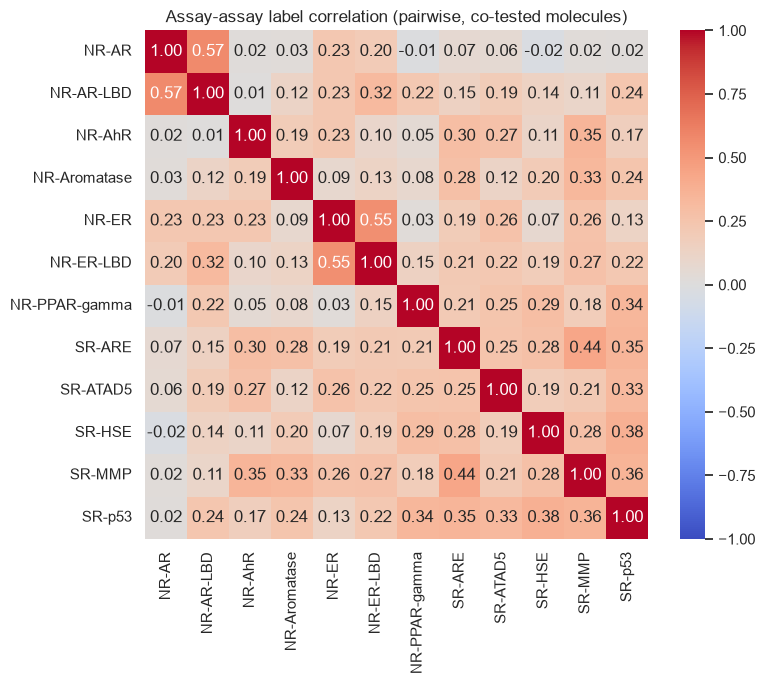

Mean within-NR correlation:   0.168
Mean within-SR correlation:   0.306
Mean NR-SR cross correlation: 0.190

Strongest assay pairs:
   NR-AR          NR-AR-LBD      +0.572
   NR-ER          NR-ER-LBD      +0.547
   SR-ARE         SR-MMP         +0.436
   SR-HSE         SR-p53         +0.381
   SR-MMP         SR-p53         +0.359
   NR-AhR         SR-MMP         +0.350
   SR-ARE         SR-p53         +0.348
   NR-PPAR-gamma  SR-p53         +0.339


In [5]:
label_corr = df[TASKS].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(label_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("Assay-assay label correlation (pairwise, co-tested molecules)")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_label_correlation.png", dpi=150)
plt.show()

nr_block = label_corr.loc[NR_TASKS, NR_TASKS].values
sr_block = label_corr.loc[SR_TASKS, SR_TASKS].values
cross_block = label_corr.loc[NR_TASKS, SR_TASKS].values

nr_mean = nr_block[np.triu_indices_from(nr_block, k=1)].mean()
sr_mean = sr_block[np.triu_indices_from(sr_block, k=1)].mean()
cross_mean = cross_block.mean()

print(f"Mean within-NR correlation:   {nr_mean:.3f}")
print(f"Mean within-SR correlation:   {sr_mean:.3f}")
print(f"Mean NR-SR cross correlation: {cross_mean:.3f}")

pairs = [
    (a, b, label_corr.loc[a, b])
    for i, a in enumerate(TASKS)
    for j, b in enumerate(TASKS)
    if j > i
]
top_pairs = sorted(pairs, key=lambda p: -p[2])[:8]
print("\nStrongest assay pairs:")
for a, b, v in top_pairs:
    print(f"   {a:<14} {b:<14} {v:+.3f}")

## Summary — decisions locked

1. **Missing rate & class balance per assay.** Missing rates range ~7-26%, positive rates range ~3-16% — every assay is both sparsely tested and heavily imbalanced.
   > **Decision: masked BCE loss (assays must be masked, not treated as negative-when-missing) + per-assay AUC as the metric (accuracy is meaningless at these positive rates).**

2. **Label co-occurrence.** Most molecules (~3,000+) have all 12 assays tested, but a long tail have as few as 1; the NR and SR panels are co-tested for ~94% of molecules, not all.
   > **Decision: per-assay masking, not per-panel — the panels are usually but not always tested together, and the partially-tested tail is too large to approximate with a coarser mask.**

3. **Per-fold positive counts.** Zero (assay, fold) pairs flagged — every assay keeps at least 20 positives in every fold. The closest call is NR-ER-LBD in val (20 positives, exactly at the threshold); next-lowest are NR-AR-LBD val (25) and NR-PPAR-gamma train (131, its smallest raw count but still comfortable in every fold). The scaffold split did **not** starve any assay's test fold the way it could have.
   > **Decision: no assay needs to be dropped or caveated for insufficient test-fold support — all 12 per-assay AUCs can be reported and compared on equal footing. Still worth a one-line caveat on NR-ER-LBD (val=20) if it turns out to be the noisiest metric during training.**

4. **Assay-assay label correlation.** The clean "NR block vs SR block" story does **not** hold. The two strongest correlations by far are same-receptor pairs measured two ways — NR-AR/NR-AR-LBD (+0.57) and NR-ER/NR-ER-LBD (+0.55) — which is closer to redundant signal than genuine multi-task transfer. Beyond those two pairs, mean within-SR correlation (0.306) is actually higher than mean within-NR correlation (0.168), and mean NR-SR cross-panel correlation (0.190) is comparable to or higher than most NR-NR pairs — e.g. SR-MMP correlates with NR-AhR (+0.35) and NR-Aromatase (+0.33) about as strongly as with other SR assays. So the real structure is: (a) two near-duplicate receptor-subunit pairs, (b) SR assays sharing a more homogeneous "general stress/reactivity" signal with each other and with several NR assays, rather than a strict NR-vs-SR split.
   > **Decision: multi-task learning is still justified — real cross-assay correlation exists — but don't market it as "recovers the NR/SR panel grouping"; the honest framing is a general-reactivity factor plus two redundant receptor pairs. Consider whether NR-AR-LBD / NR-ER-LBD add enough independent signal over their full-length counterparts to justify separate output heads, versus being useful mainly as auxiliary regularization.**

5. **Scaffold split.** Already decided in the previous pass: top-10 scaffolds cover 48% of the dataset (2,404 unique scaffolds, less concentrated than ESOL's 64%/269) — concentrated enough to justify a scaffold split over random, already built (`data/processed/tox21_splits.csv`, 80/10/10).